### Geo-Deep-Learning (GDL)

*Using AI to understand the earth from geospatial data*

**A mental model of geo-deep-learning**

**Geo**: Geospatial data in various forms; satellite images, aerial photos, and vector data (points, lines). These are our inputs.

**Deep-Learning**: Deep learning is a family of algorithms that learn patterns from large datasets to optimize or solve tasks.


Geospatial Tasks:

- Classification (What is this area? forest or water?)
- Detection (Where are the houses, fires, urban changes?)
- Segmentation (Pixel-level mapping of land cover or flood zones)
- Prediction (Weather forecast, likelihood of natural disasters)

![alt text](geo_tasks_lite.png)

**Applying Deep Learning to geospatial tasks entails**:

- understanding your data and problem
- understanding your model (mathematical form of a given model)
- understanding how to fit your model (optimization and loss functions)
- understanding how to evaluate your model (evaluation metrics)
- understanding techniques to train your model effectively (data types, precision and GPU hardware)

**GeoAI Tools**

- **geo-deep-learning**: https://github.com/NRCan/geo-deep-learning
- torchgeo: https://github.com/torchgeo/torchgeo

![alt text](logo.png)

**Geo-Deep Learning (GDL) is a modular framework for applying state-of-the-art deep learning models to geospatial tasks.**

**Features**

- **Modular Architecture**: Encoder-neck-decoder pattern with interchangeable components
- **Multiple Model Types**: UNet++, SegFormer, DOFA (Dynamic-one-for-all Architecture)

```

├── models/
│   ├── encoders/          # DOFA, MixTransformer backbones
│   ├── necks/             # Multi-level feature processing
│   ├── decoders/          # UperNet decoder implementation
│   └── heads/             # Segmentation heads (FCN, etc.)
├── datamodules/           # Lightning DataModules
├── datasets/              # WebDataset and CSV dataset implementations
├── tasks_with_models/     # Lightning modules for training
├── tools/                 # Utilities, callbacks, visualization
└── samplers/              # Custom data sampling strategies

```

**Creating an Enviroment**

**Install miniconda**: https://www.anaconda.com/docs/getting-started/miniconda/install#linux-2

**Clone GDL**:

```shell
$ git clone https://github.com/NRCan/geo-deep-learning.git
$ cd geo-deep-learning
```

```shell
$ conda create --name geo-deep-env python=3.11
$ conda activate geo_deep_env
$ pip install -r requirements.txt
```



*python: preferred programming language*

*pytorch: deep learning framework*

*pytorch-lightning: extension of pytorch with a simpler interface*

### GDL Walkthrough

##### Imports and environment check

In [1]:
import time

start_total = time.time()

print("Importing required libraries...")

# Core modules
# Data and ML
import csv
import platform
import sys
import warnings
import zipfile
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import torch
from PIL import Image

# Remove warnings from not georeferenced dataset (for this example only)
from rasterio.errors import NotGeoreferencedWarning
from tqdm import tqdm

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

# # Append root path to make module work from notebook (might differ in your environment)
sys.path.append("..")

# Environment info
print(f"Imports done in {time.time() - start_total:.2f} seconds\n")

# Print system info
print("\n--- Environment Info ---")
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("Torch:", torch.__version__)
print("Lightning:", L.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

Importing required libraries...
Imports done in 2.77 seconds


--- Environment Info ---
Python: 3.11.5
OS: Linux-5.15.0-153-generic-x86_64-with-glibc2.35
Torch: 2.3.1+cu121
Lightning: 2.4.0
Device: CUDA


## Extract and Visualize dataset 
   
**Note**: In this subset, the images and labels are **already split into 512×512 patches**

../data/waterloo_subset_512 already extracted.


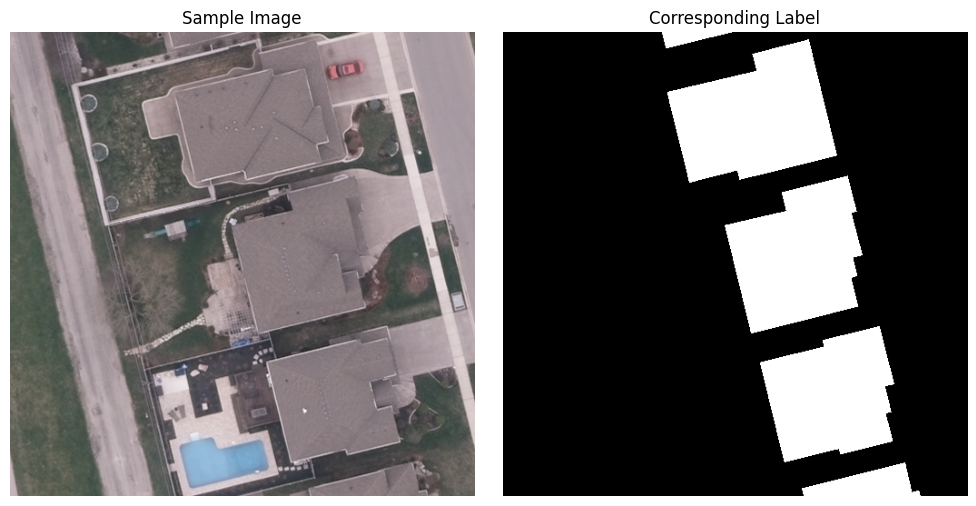

In [2]:
# Define path to the archive and extract location
zip_path = Path("../data/waterloo_subset_512.zip")
extract_dir = zip_path.with_suffix("")  # removes .zip

# Unzip only if not already done
if not extract_dir.exists():
    print(f"Extracting to {extract_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print(f"{extract_dir} already extracted.")

# Sanity check: print 1 image/label pair from 'trn' split
img_dir = extract_dir / "trn" / "image"
lbl_dir = extract_dir / "trn" / "label"

sample_imgs = sorted(img_dir.glob("*.tif"))
if sample_imgs:
    sample_path = sample_imgs[0]
    label_path = lbl_dir / sample_path.name

    with rio.open(sample_path) as img_ds:
        img = img_ds.read([1, 2, 3])  # RGB
    with rio.open(label_path) as lbl_ds:
        lbl = lbl_ds.read(1)  # single-channel label

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img.transpose(1, 2, 0).astype("uint8"))
    ax1.set_title("Sample Image")
    ax1.axis("off")

    ax2.imshow(lbl, cmap="gray")
    ax2.set_title("Corresponding Label")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No images found in trn/image/")

##### Prepare Dataset for training 

In [3]:
# Remap all labels in the dataset
for split in ["trn", "val", "tst"]:
    lbl_dir = extract_dir / split / "label"
    if not lbl_dir.exists():
        continue

    for lbl_path in tqdm(
        sorted(lbl_dir.glob("*.tif")),
        desc=f"Remapping {split} labels",
    ):
        with rio.open(lbl_path) as lbl_ds:
            lbl = lbl_ds.read(1)

            # Remap 255 → 1
            lbl = np.where(lbl == 255, 1, lbl).astype("int16")

            # Save back (overwrite in place)
            profile = lbl_ds.profile
            profile.update(dtype="int16", count=1)

        with rio.open(lbl_path, "w", **profile) as dst:
            dst.write(lbl, 1)

# Create a CSV file for each split
splits = ["trn", "val", "tst"]

for split in splits:
    img_dir = extract_dir / split / "image"
    lbl_dir = extract_dir / split / "label"
    csv_path = extract_dir / f"{split}.csv"

    # Collect matching image–label pairs
    rows = []
    for img_path in sorted(img_dir.glob("*.tif")):
        lbl_path = lbl_dir / img_path.name
        if lbl_path.exists():
            rows.append([str(img_path.resolve()), str(lbl_path.resolve())])
        else:
            print(f"No matching label found for {img_path.name}")

    # Write CSV
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f, delimiter=";")
        writer.writerows(rows)

    print(f"Wrote {len(rows)} pairs to {csv_path.name}")

Remapping tst labels: 100%|██████████| 8/8 [00:00<00:00, 250.78it/s]

Wrote 32 pairs to trn.csv
Wrote 8 pairs to val.csv
Wrote 8 pairs to tst.csv


##### Create DataModules

In [4]:
from geo_deep_learning.datamodules.csv_datamodule import CSVDataModule
from geo_deep_learning.datasets.csv_dataset import CSVDataset

# Define dataset paths previously extracted from the ZIP
dataset_root = extract_dir


# Change mask dtype to match SoftCrossEntropyLoss
def _load_mask_int64(self, index: int):
    """Load mask as int64 (safe for CE/SoftCE etc)."""
    mask_path = self.files[index]["mask"]
    mask_name = Path(mask_path).name
    with rio.open(mask_path) as mask:
        mask_array = mask.read(1).astype(np.int64)  # categorical labels
        mask_tensor = torch.from_numpy(mask_array)  # keep as int64
    return mask_tensor, mask_name


# Monkeypatch once at the class level to load as int64 for CE / SoftCrossEntropy
CSVDataset._load_mask = _load_mask_int64

# Normalization values (random RGB stats for the demo; adjust to match dataset)
mean = [0.5, 0.5, 0.5]
std = [0.2, 0.2, 0.2]

# Initialize DataModule
dm = CSVDataModule(
    batch_size=4,
    num_workers=1,  # Can be increased for real training
    mean=mean,
    std=std,
    csv_root_folder=str(dataset_root),
    patches_root_folder=str(dataset_root),
)

dm.setup()

# Test one sample for sanity
sample = dm.train_dataset[0]
print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([512, 512])


##### Visualize Data from Datamodule

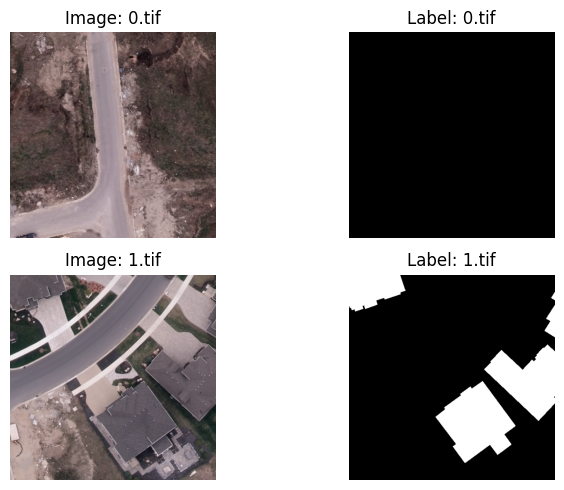

In [5]:
# How many samples to display
num_samples = 2
samples = dm.val_dataset.files[:num_samples]

fig, axes = plt.subplots(num_samples, 2, figsize=(8, 2.5 * num_samples))

for idx, pair in enumerate(samples):
    img_path = pair["image"]
    lbl_path = pair["mask"]

    # Load image
    with rio.open(img_path) as img_ds:
        image_np = img_ds.read().transpose(1, 2, 0).astype(np.float32)
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

    # Load label
    with rio.open(lbl_path) as lbl_ds:
        label_np = lbl_ds.read(1)

    # Plot image
    axes[idx, 0].imshow(image_np)
    axes[idx, 0].set_title(f"Image: {img_path.name}")
    axes[idx, 0].axis("off")

    # Plot label
    axes[idx, 1].imshow(label_np, cmap="gray")
    axes[idx, 1].set_title(f"Label: {lbl_path.name}")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

##### Define the model for training

- Instantiate the `SegmentationUnetPlus` model from `geo_deep_learning/tasks_with_models/segmentation_unetplus.py`
- Configure the model with:
    - A **ResNet34** encoder (other encoders can be chosen depending on your needs and resources)  
    - **3 input channels** (RGB imagery)
    - **2 output classes** (background vs building) 
    - **SoftCrossEntropyLoss** as the loss function (robust to class imbalance, smooth factor = 0.1)  
    - **Adam** optimizer with a constant learning rate, and a **ReduceLROnPlateau** scheduler 

In [6]:
from segmentation_models_pytorch.losses import SoftCrossEntropyLoss
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from geo_deep_learning.tasks_with_models.segmentation_unetplus import (
    SegmentationUnetPlus,
)

# Loss function instance (multi-class, 2 classes: background + buildings)
loss_fn = SoftCrossEntropyLoss(smooth_factor=0.1)

# Optimizer and scheduler configs
optimizer_class = Adam
optimizer_kwargs = {"lr": 1e-4}

scheduler_class = ReduceLROnPlateau
scheduler_kwargs = {
    "mode": "min",
    "factor": 0.1,
    "patience": 10,
    "cooldown": 1,
    "min_lr": 1e-8,
}

# Model instantiation
model = SegmentationUnetPlus(
    encoder="resnet34",  # backbone encoder
    image_size=(512, 512),
    weights=None,
    in_channels=3,
    max_samples=4,  # visualize up to 4 samples per val epoch
    num_classes=2,
    loss=loss_fn,
    optimizer=lambda params: optimizer_class(params, **optimizer_kwargs),
    scheduler=scheduler_class,
    scheduler_config={
        "interval": "epoch",
        "frequency": 1,
        "monitor": "val_loss",
    },
    class_labels=["background", "buildings"],
    class_colors=["#000000", "#FF0000"],
    weights_from_checkpoint_path=None,
)

/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


##### Train the model

Launch training with **pytorch-Lightning’s `Trainer`**:

- Set up **MLflow** logger  
-  Define a few training parameters:  
   - run for 10 epochs (adjustable)  
   - run on GPU `(accelerator="gpu")`  
   - track progress with a TQDM progress bar callback  
-  Call `trainer.fit()` with the model and DataModule

In [7]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import MLFlowLogger

logger = MLFlowLogger(
    experiment_name="unet_segmentation",
    tracking_uri="file:./mlruns",
)

# Define trainer
trainer = Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    callbacks=[TQDMProgressBar()],
    logger=logger,
    log_every_n_steps=1,
)

# Train model
trainer.fit(model, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:44: Attribute 'optimizer' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['optimizer'])`.
INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for trn split with 32 patches
INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for val split with 8 patches
INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for tst split with 8 patches
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                 | Type                 | Params | Mode 
----------------------------------------------------------------------
0 | loss                 | SoftCrossEntropyLoss | 0      | train
1 | iou_metric           | MeanIoU              | 0      | train
2 | iou_classwis

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:368: You have overridden `on_before_batch_transfer` in `LightningModule` but have passed in a `LightningDataModule`. It will use the implementation from `LightningModule` instance.


/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 8/8 [00:01<00:00,  4.63it/s, v_num=6a99, val_loss=0.279, train_loss=0.320]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 8/8 [00:02<00:00,  3.36it/s, v_num=6a99, val_loss=0.279, train_loss=0.320]


In [9]:
trainer.checkpoint_callback.best_model_path

'./mlruns/424225768273235719/b90fe207c14e4dbbbab7d107822e6a99/checkpoints/epoch=9-step=80.ckpt'

#### Plot Train and Validation loss

<Axes: >

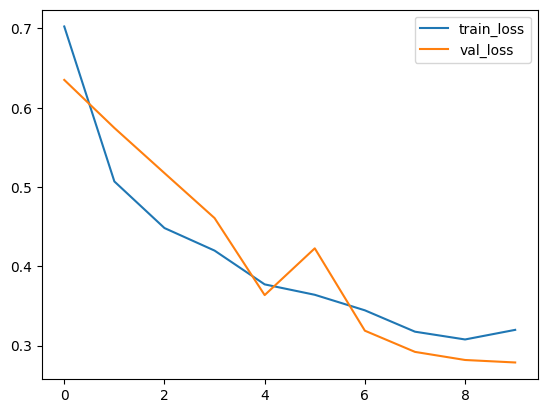

In [10]:
import mlflow
import pandas as pd

client = mlflow.tracking.MlflowClient()
run_id = logger.run_id

# Fetch metrics
metrics = client.get_metric_history(run_id, "train_loss")
train_loss = [m.value for m in metrics]

metrics = client.get_metric_history(run_id, "val_loss")
val_loss = [m.value for m in metrics]

# Plot with pandas
pd.DataFrame({"train_loss": train_loss, "val_loss": val_loss}).plot()

##### Evaluate model on test set

In [11]:
# Run evaluation on the test set (defined by the csv_datamodule)
trainer.test(
    model,
    datamodule=dm,
    ckpt_path=trainer.checkpoint_callback.best_model_path,
)

INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for trn split with 32 patches
INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for val split with 8 patches
INFO:geo_deep_learning.datasets.csv_dataset:Created dataset for tst split with 8 patches
Restoring states from the checkpoint path at ./mlruns/424225768273235719/b90fe207c14e4dbbbab7d107822e6a99/checkpoints/epoch=9-step=80.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ./mlruns/424225768273235719/b90fe207c14e4dbbbab7d107822e6a99/checkpoints/epoch=9-step=80.ckpt
/export/sata01/wspace/conda_envs/geo-inference_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:geo_deep_learning.tasks_with_models.segmentation_unetplus:Logging visualizations


Testing DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.85it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    meaniou_background     │    0.9409292340278625     │
│     meaniou_buildings     │    0.8147454261779785     │
│         test_loss         │    0.31693753600120544    │
└───────────────────────────┴───────────────────────────┘

[{'meaniou_background': 0.9409292340278625,
  'meaniou_buildings': 0.8147454261779785,
  'test_loss': 0.31693753600120544}]

#### Visualize test results

Experiment: 424225768273235719 Run: b90fe207c14e4dbbbab7d107822e6a99
Artifact dir: mlruns/424225768273235719/b90fe207c14e4dbbbab7d107822e6a99/artifacts/test
Found 4 images under mlruns/424225768273235719/b90fe207c14e4dbbbab7d107822e6a99/artifacts/test


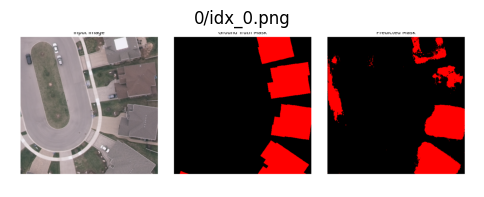

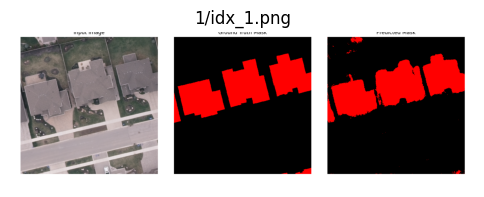

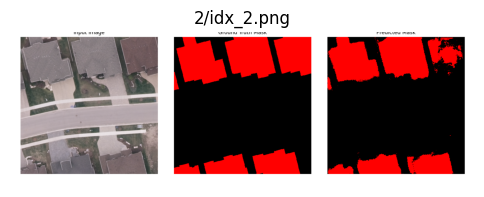

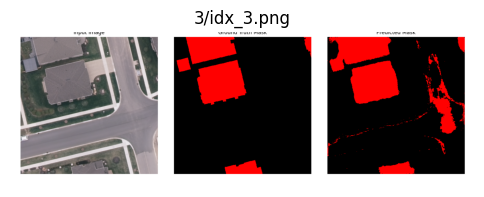

In [12]:
# Identify MLflow experiment/run ids
print("Experiment:", logger.experiment_id, "Run:", logger.run_id)
experiment_id = logger.experiment_id
run_id = logger.run_id

# Path to artifacts produced during test loop
artifact_dir = Path("mlruns") / str(experiment_id) / str(run_id) / "artifacts" / "test"
print("Artifact dir:", artifact_dir)

# Find prediction PNGs
img_files = sorted(artifact_dir.rglob("*.png"))
print(f"Found {len(img_files)} images under {artifact_dir}")

# Display first few predictions
for img_file in img_files[:8]:
    img = Image.open(img_file)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(str(img_file.relative_to(artifact_dir)))
    plt.axis("off")
    plt.show()